## What is Exploratory Data Analysis (EDA)?

Exploratory Data Analysis (EDA) is the process of understanding a dataset before performing deeper analysis or modeling. It helps uncover patterns, identify issues, and generate questions through summaries and visualizations.

---

## Main Steps of EDA

- **Step 1: Dataset Overview:** Understand the structure of the data, including the number of rows and columns, what each row represents, and the types of variables in each column.

- **Step 2: Summary Statistics:** Examine key numerical summaries such as averages, ranges, and missing values to get a high-level understanding of the data.

- **Step 3: Visualizations:** Create simple charts like histograms, box plots, and bar charts to explore distributions, trends, and potential outliers.

- **Step 4: Observations & Insights:** Identify patterns, note anything unusual, and ask questions that can guide further analysis.

---

## Goal of EDA

By the end of this section, you should have a clear understanding of your dataset, recognize key patterns or trends, and develop questions or ideas for deeper analysis.

## Step 0: Imports & Data

In [2]:
# core imports

import pandas as pd  # data manipulation and analysis (DataFrames)
import numpy as np  # numerical operations and arrays
import matplotlib.pyplot as plt  # basic plotting (histograms, bar charts, etc.)
import seaborn as sns  # cleaner and more advanced visualizations
import datetime as dt  # working with dates and time-based data

sns.set() # makes plots look nicer by default

# additional libraries
# `- plotly` → interactive visualizations
# - `scipy` → statistical analysis
# - `sklearn` → machine learning and modeling

In [4]:
# load dataset

# replace 'cleaned_dataset.csv' with your actual file name
df = pd.read_csv("../data/merged/merged_dataset.csv")
# preview the first few rows to confirm it loaded correctly
df.head()

# optional: view basic info about the dataset
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 94831 entries, 0 to 94830
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   borough                 94831 non-null  str    
 1   street                  94831 non-null  str    
 2   fromSt                  94831 non-null  str    
 3   toSt                    94831 non-null  str    
 4   datetime                94831 non-null  str    
 5   Yr                      94831 non-null  int64  
 6   M                       94831 non-null  int64  
 7   D                       94831 non-null  int64  
 8   HH                      94831 non-null  int64  
 9   MM                      94831 non-null  int64  
 10  Vol                     94831 non-null  float64
 11  SegmentID               94831 non-null  int64  
 12  WktGeom                 94831 non-null  str    
 13  Direction               94831 non-null  str    
 14  sid                     85293 non-null  float64
 

(94831, 26)

## Step 1: Dataset Overview

In [11]:
# Step 1. Dataset Overview - Code
# Teammate Responsible: Elaine

# check the shape of the dataset (rows, columns)
df.shape

# view the column names
df.columns

# preview the first 5 rows
df.head()

# preview the last 5 rows
df.tail()

# get general information about the dataset
# includes data types and non-null counts
df.info()

# check data types for each column
df.dtypes

# optional: view a random sample of rows
df.sample(5)

<class 'pandas.DataFrame'>
RangeIndex: 94831 entries, 0 to 94830
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   borough                 94831 non-null  str    
 1   street                  94831 non-null  str    
 2   fromSt                  94831 non-null  str    
 3   toSt                    94831 non-null  str    
 4   datetime                94831 non-null  str    
 5   Yr                      94831 non-null  int64  
 6   M                       94831 non-null  int64  
 7   D                       94831 non-null  int64  
 8   HH                      94831 non-null  int64  
 9   MM                      94831 non-null  int64  
 10  Vol                     94831 non-null  float64
 11  SegmentID               94831 non-null  int64  
 12  WktGeom                 94831 non-null  str    
 13  Direction               94831 non-null  str    
 14  sid                     85293 non-null  float64
 

,borough,street,fromSt,toSt,datetime,Yr,M,D,HH,MM,...,aggregation_period_sec,n_samples,median_tt_sec,median_speed_fps,id,speed,travel_time,status,link_id,transcom_id
45356,Manhattan,EAST 116 STREET,1 Avenue,Pleasant Avenue,2023-12-02 20:30:00,2023,12,2,20,30,...,535.000000,13.750000,93.922222,8.707833,224.43650,13.089285,308.70625,-59.64050,4.534736e+06,4.534736e+06
64517,Manhattan,WILLIS AVENUE BRIDGE,Harlem River Drive Exit 18 Nb,Harlem River Shoreline,2023-10-24 22:30:00,2023,10,24,22,30,...,535.000000,13.750000,93.922222,8.707833,224.43650,13.089285,308.70625,-59.64050,4.534736e+06,4.534736e+06
74496,Queens,DE KALB AVENUE,Seneca Avenue,Cypress Avenue,2024-06-13 09:30:00,2024,6,13,9,30,...,465.168539,16.696629,164.898876,10.107191,309.70475,37.225540,254.90225,-12.39775,4.526144e+06,4.526144e+06
30651,Brooklyn,LIVONIA AVENUE,New Lots Line,New Lots Line,2024-10-30 05:15:00,2024,10,30,5,15,...,528.260870,50.826087,192.684783,20.040217,258.45950,23.309980,251.67750,-35.62775,4.665010e+06,4.665010e+06
83501,Queens,NORTHERN BOULEVARD,193 Street,194 Street,2024-11-24 11:15:00,2024,11,24,11,15,...,465.168539,16.696629,164.898876,10.107191,309.70475,37.225540,254.90225,-12.39775,4.526144e+06,4.526144e+06


### Step 1: Dataset Overview - Analysis
1. What does each row represent?
    Each row represents a specific road segment. Its traffic conditions are included. 
2. What does each column represent?
    Each column represents a specific traffic condition that's measured for each road. 
    There's borough, the street of the road segment, the timestamp of measurement, and
    the beginning and ends of the road segment (fromSt toSt). 
    There's also average speed of the road and time in seconds to traverse it. 
    • aggregation_period_sec → time window used
	• n_samples → number of observations used
    "id" columns are road segment identifiers. 
3. How many rows and columns are there?
    From running "df.shape" we see there are 25 rows and 26 columns. 
4. What types of data are in each column (numerical, categorical, etc.)?
    • borough, street --> categorical
	• datetime → datetime (year:month:day, time)
    • numerical --> speed, travel_time, Yr/M/D/HH/MM
    • ID --> all "id" columns (e.g. "link_id", "transcom_id")
5. Are there any obvious issues with the data?
    The Yr/M/D/HH/MM columns probably aren't necessary since we already have datetime.
    "Some missing values are only in the dataset1 columns for Bronx, since dataset1 didn’t have Bronx data."
    The units of the "speed" column aren't labeled. Same for median_speed_fps (is it feet?)
    Unsure what column "status" is, and why it's negative. 

## Step 2: Summary Statistics

In [ ]:
# Step 2. Summary Statistics - Code
# Teammate Responsible: Elaine

# generate summary statistics for all numerical columns
df.describe()

# include all columns (numerical + categorical) for a fuller view
df.describe(include='all')

# # check unique values for categorical columns
# df['borough'].nunique()

# # view value counts for a categorical column
# df['borough'].value_counts()

# # calculate basic statistics manually for a specific numerical column
# df['column_name'].mean()    # average
# df['column_name'].median()  # middle value
# df['column_name'].min()     # minimum value
# df['column_name'].max()     # maximum value
# df['column_name'].std()     # standard deviation

# % check skew for numerical columns to understand distribution
df.skew(numeric_only=True)

# % checking for rush hour "peaks" in activity by hour of the day
df["HH"].value_counts().sort_index()
df.groupby("HH")["speed"].mean()

# % speed by borough
df.groupby("borough")["speed"].mean()

HH
0     157.743974
1     157.899137
2     157.887945
3     157.820314
4     157.844797
5     157.711535
6     157.430143
7     157.261689
8     157.081109
9     157.058648
10    157.023801
11    156.914156
12    156.758854
13    156.748360
14    156.862727
15    156.836835
16    156.793884
17    156.915172
18    156.938640
19    156.930118
20    156.859683
21    157.061848
22    157.324810
23    157.572934
Name: median_tt_sec, dtype: float64

### Step 2: Summary Statistics - Analysis
- What are the averages, ranges, and spreads of key numerical columns?
    - Averages:
        - Yr: 2023.60
        - n_samples: 28.07
        - median_tt_sec (travel time): 157.22 sec
        - median_speed_fps: 13.54, unit unknown per sec
        - speed: 25.46, unit unknown
    - Ranges: 
        - Yr: 2 years
        - n_samples: 37.07
        - median_tt_sec: 206.32
        - median_speed_fps: 12.81
        - speed: 24.13
    - Spreads (using standard deviation): 
        - Yr: 0.64
        - n_samples: 16.84
        - median_tt_sec: 49.50
        - median_speed_fps: 5.28
        - speed: 9.44
- How many unique categories exist in categorical columns?
    - "borough": Just the 5 unique boroughs of the city. (Brooklyn/Manhattan/Queens have by fr the most, followed by Bronx and then Staten Island)
    - "streets": 97 unique categories
- Are there columns with skewed distributions or dominant categories?
    - Vol, large positive skew, 2.40
    - travel_time, large negative skew, -2.43
    - aggregation_period_sec, large positive skew, 3.08
    - technically SegmentID and id are positively skewed but those are ids so they  weren't included
- Do any numbers or patterns stand out as interesting?
    - Relatively even number of data points for all hours of the day. 
    - Relatively even speeds for all hours of the day.
    - Speed by borough - Manhattan speeds were almost 1/3rd of Bronx, Queens, & Staten Island. Queens had the fastest speeds. 

## Step 3: Visualizations

In [ ]:
# Step 3. Visualizations - Code
# Teammate Responsible: Full Name

# histogram for a numerical column
sns.histplot(df['column_name'], bins=20)  # adjust bins as needed
plt.title('Distribution of column_name')
plt.xlabel('column_name')
plt.ylabel('Frequency')
plt.show()

# box plot for a numerical column (to identify outliers)
sns.boxplot(x=df['column_name'])
plt.title('Boxplot of column_name')
plt.show()

# bar chart for a categorical column
sns.countplot(x='column_name', data=df)
plt.title('Counts of column_name')
plt.xlabel('column_name')
plt.ylabel('Count')
plt.show()

# scatter plot for two numerical columns (to see relationship/trend)
sns.scatterplot(x='column_x', y='column_y', data=df)
plt.title('column_x vs column_y')
plt.xlabel('column_x')
plt.ylabel('column_y')
plt.show()

In [ ]:
# NOTE: Wait until speed column is fixed before running this cell again

# box plot to compare speed across different boroughs
sns.boxplot(x="borough", y="speed", data=df)
plt.title('Speed Distribution by Borough')
plt.xlabel('Borough')
plt.ylabel('Speed')
plt.axhline(df["speed"].mean(), linestyle="--", color="red", label="City Average")
plt.legend()
plt.show()

# scatter plot to see relationship between volume and speed
# Purpose is to verify if higher traffic volume correlates with lower speeds (congestion)
sns.scatterplot(x="Vol", y="speed", data=df, alpha=0.2)
plt.title('Volume vs Speed')
plt.xlabel('Volume')
plt.ylabel('Speed')
plt.show()

# heatmap to visualize average speed by day of week and hour of day
df["dayofweek"] = pd.to_datetime(df["datetime"]).dt.day_name()
pivot = df.pivot_table(values="speed", index="dayofweek", columns="HH", aggfunc="mean")
sns.heatmap(pivot, cmap="RdYlGn")
plt.title('Average Speed by Day of Week and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

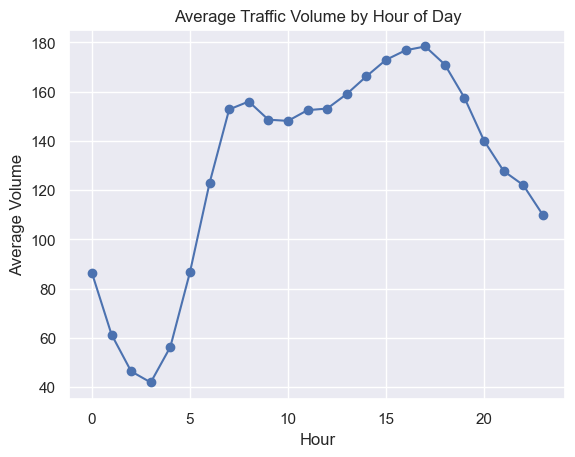

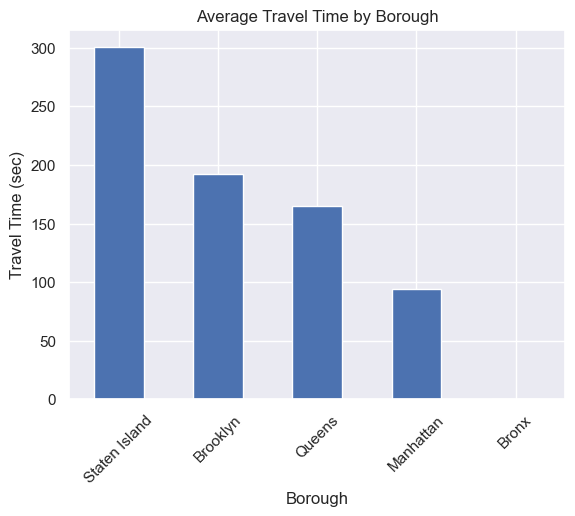

borough                       5
street                       97
fromSt                       93
toSt                         87
datetime                  26367
Yr                            3
M                             7
D                            31
HH                           24
MM                            4
Vol                         987
SegmentID                   122
WktGeom                     123
Direction                     4
sid                           4
link_length_ft                4
aggregation_period_sec        4
n_samples                     4
median_tt_sec                 4
median_speed_fps              4
id                            5
speed                         5
travel_time                   5
status                        5
link_id                       5
transcom_id                   5
dayofweek                     7
dtype: int64


In [ ]:
# line plot to show average traffic volume by hour of day (to identify rush hours)
df.groupby("HH")["Vol"].mean().plot(kind="line", marker="o")
plt.title("Average Traffic Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Volume")
plt.show()

# bar plot to compare average travel time across different boroughs
df.groupby("borough")["median_tt_sec"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Travel Time by Borough")
plt.ylabel("Travel Time (sec)")
plt.xlabel("Borough")
plt.xticks(rotation=45)
plt.show()

print(df.nunique())


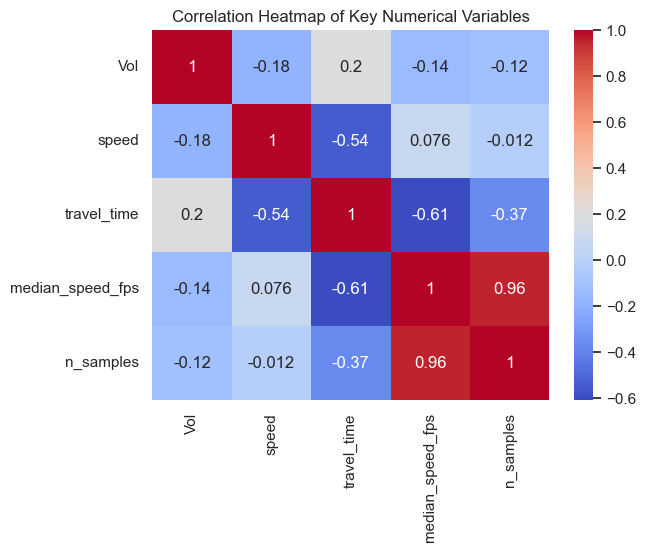

In [19]:
# heatmap to show correlations between key numerical variables (e.g., volume, speed, travel time)
# Can use this to find columns to get rid of to help the ML algo later on
sns.heatmap(df[["Vol","speed","travel_time","median_speed_fps","n_samples"]].corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap of Key Numerical Variables')
plt.show()

### Step 3: Visualizations - Analysis
- What does the distribution of each numerical column look like?
- Are there any outliers visible in boxplots?
- Which categories are most frequent in categorical columns?
- Do scatter plots reveal any clear trends or relationships?

## Step 4: Observations & Insights

In [ ]:
# Step 4. Observations & Insights - Code
# Teammate Responsible: Full Name

# check for correlations among all numerical columns
df.corr()

# quick pairplot to see relationships between numerical columns
sns.pairplot(df)
plt.show()

# explore a subset of the data if needed
# example: filter by a category
subset = df[df['column_name'] == 'specific_value']
subset.describe()
subset.head()

# create extra visualizations if something stands out
# example: scatter plot of two columns
sns.scatterplot(x='column_x', y='column_y', data=df)
plt.show()

### Step 4: Observations & Insights - Analysis

Use this section to summarize your findings from the EDA. Cover the following points:

- **Patterns:** Note any trends or consistent patterns you see in the data.  
- **Relationships:** Highlight correlations or interesting interactions between columns.  
- **Anomalies/Outliers:** Point out anything unusual or unexpected in the dataset.  
- **Questions for Further Analysis:** List questions that arise from your observations, which could guide deeper exploration or modeling.  
